In [1]:
### Natalie M. Larsen ###
### Final Project ###
# Hypothesis: For Florida reef sites, short-term hurricane exposure (storm-driven mixing/upwelling) is associated with higher coral survival. Chronic thermal stress from climate change pressures is associated with lower survival and degradation. In other words, mortality is driven primarily by heat and disease, not by hurricanes which actually aids in maintaining ecological coral reef health.#


## Loading all ouur modules at once
# Data storage methods and analysis toolkits
import pandas as pd
import numpy as np 
import scipy


#Graphing
import matplotlib as mpl
import matplotlib.pyplot as plt

# Functions for the PCA
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from scipy import stats

In [2]:
### Loading our data, Template
df = pd.read_csv(input(), sep="\t") # loading data as a data frame
print(df) ### optionally here for debugging
#~/env3040/env3040_lectures/location_temp.txt


 ~/env3040/env3040_lectures/location_temp.txt


       Pulaski Light Recorded Temperature (Celsius)  \
0                                            24.690   
1                                            24.665   
2                                            24.666   
3                                            24.653   
4                                            24.629   
...                                             ...   
32155                                        25.538   
32156                                        25.525   
32157                                        25.538   
32158                                        25.550   
32159                                        25.562   

       Sombrero  Recorded Temperature (Celsius)  \
0                                        25.150   
1                                        25.138   
2                                        25.101   
3                                        25.077   
4                                        25.065   
...                              

In [3]:
# First data set #
# Link 1: Discusses octoral dynamics of coral reefs off the coast of Florida
# use increasing octoral density from the time period, describes phenomnenon of increase in coral density even with hurricanes
# use data from hurricanes, and heatwaves given in figures to describe , “In Figures S1, S2, and S7, every major decline in octocoral cover or recruit density aligns with years marked as marine heatwaves (2014–2015, 2017, 2019, and especially 2023). These declines follow dashed vertical lines in the figures, highlighting thermal anomalies rather than storm impacts.”
# use the solid vertical lines for:
# after Hurricane Irma (2017): Cover dips slightly in some habitats, Density recovers or increases in most regions, Recruit density remains stable or increases 
# after Hurricane Ian (2022), No major downward trend in density or recruitment, Stability persists through 2023 until the heatwave-induced crash

#variables: octoral density with time period

In [4]:
# Second data set #
# Link 2: Discusses upwelling  and natural impacts on Acropora palmata for coastal florida ecosystems, also discusses other potential factors including marine disease and climate change.
# The highest mortality occurred at: Sombrero Reef (SMK) – Many ramets dead (e.g., CF4 “537 dead,” CN2 “533 dead,” HS1 “530 dead,” ML2 “538 dead”), Fowey Rocks (FWY) – Several dead ramets.
# Both SMK and FWY are warmer, shallower, more thermally stressed sites (visible in Figure 1).
# use underwater temp data to NOV2015 and to JULY2024
# use figure 1 mortality status chart as well

#variables: mortality rate and type of reef, temperatures recorded for each reef type

In [5]:
# Third data set #
# Link 3: Discusses how temperature and disease stress threatens coral species, Dendrogyra cylindrus in Southeast Florida
# use supplementary table 1 to find mortality rates for coral species after date of first disease
# reference underwater temp data from second data set

# date of first disease and mortality rate

In [6]:
#### Data Desription ###
# 1
df.mean(axis=0)

Pulaski Light Recorded Temperature (Celsius)       27.188831
Sombrero  Recorded Temperature (Celsius)           27.884323
Fowey Recorded Temperature (Celsius)               27.616624
Crocker Recorded Temperature (Celsius)             27.769321
Pulaski West Recorded Temperature (Celsius)        27.240491
Sample Number (From Jan. 1-Nov. 30, 2020)       16080.500000
dtype: float64

In [7]:
# 1 CONT.
df.median(axis=0)

Pulaski Light Recorded Temperature (Celsius)       27.481
Sombrero  Recorded Temperature (Celsius)           28.147
Fowey Recorded Temperature (Celsius)               27.604
Crocker Recorded Temperature (Celsius)             27.949
Pulaski West Recorded Temperature (Celsius)        27.653
Sample Number (From Jan. 1-Nov. 30, 2020)       16080.500
dtype: float64

In [8]:
# 1 CONT.
df.std(axis=0)

Pulaski Light Recorded Temperature (Celsius)       2.821320
Sombrero  Recorded Temperature (Celsius)           2.253480
Fowey Recorded Temperature (Celsius)               2.135887
Crocker Recorded Temperature (Celsius)             2.143584
Pulaski West Recorded Temperature (Celsius)        2.848680
Sample Number (From Jan. 1-Nov. 30, 2020)       9283.936665
dtype: float64

In [9]:
# 1 CONT.
df.mean(axis=0)/df.std(axis=0)

Pulaski Light Recorded Temperature (Celsius)     9.636919
Sombrero  Recorded Temperature (Celsius)        12.373896
Fowey Recorded Temperature (Celsius)            12.929814
Crocker Recorded Temperature (Celsius)          12.954623
Pulaski West Recorded Temperature (Celsius)      9.562496
Sample Number (From Jan. 1-Nov. 30, 2020)        1.732078
dtype: float64

In [10]:
df.max(axis=0)

Pulaski Light Recorded Temperature (Celsius)       31.561
Sombrero  Recorded Temperature (Celsius)           33.027
Fowey Recorded Temperature (Celsius)               32.459
Crocker Recorded Temperature (Celsius)             31.663
Pulaski West Recorded Temperature (Celsius)        31.740
Sample Number (From Jan. 1-Nov. 30, 2020)       32160.000
dtype: float64

In [11]:
# 1 CONT.
df.columns
# I sorted data in excel before entering data into python. Extracted temperature data and then sorted for data only in 2020 and not include the dates after sampling ocurred (All of December). 
# I organized each site in correspondance with data for mortality of coral to determine what locations experienced the highest temperatures and if that corresponds with the mortality rate of each location. 

Index(['Pulaski Light Recorded Temperature (Celsius)',
       'Sombrero  Recorded Temperature (Celsius)',
       'Fowey Recorded Temperature (Celsius)',
       'Crocker Recorded Temperature (Celsius)',
       'Pulaski West Recorded Temperature (Celsius)',
       'Sample Number (From Jan. 1-Nov. 30, 2020)'],
      dtype='object')

In [ ]:
#comparing two variables
# In this case, we will compare the temperatures at each site to the sample number. A sample is taken every 15 minutes for each location. Therefore sample 1 is on 01/01/2025 at 0:00 and the final sample is on 11/30/25 23:45.
# By taking the temperature at each site we are able to compare this necessary data to coral mortality rates and hurricane data (corresponding to 2020 but can be evaluated for other years as well).


Pulaski Light Recorded Temperature (Celsius)
Sombrero  Recorded Temperature (Celsius)
Fowey Recorded Temperature (Celsius)
Crocker Recorded Temperature (Celsius)
Pulaski West Recorded Temperature (Celsius)
Sample Number (From Jan. 1-Nov. 30, 2020)


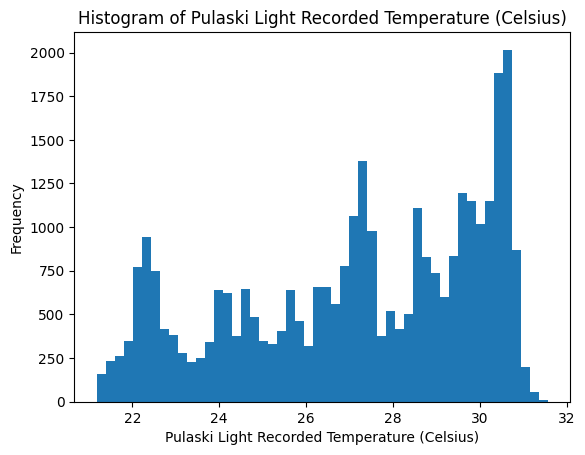

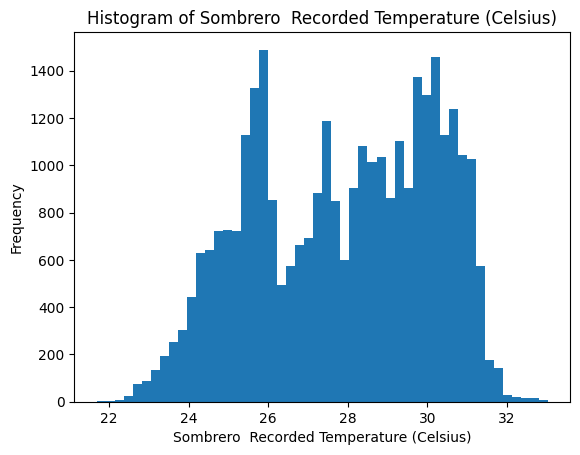

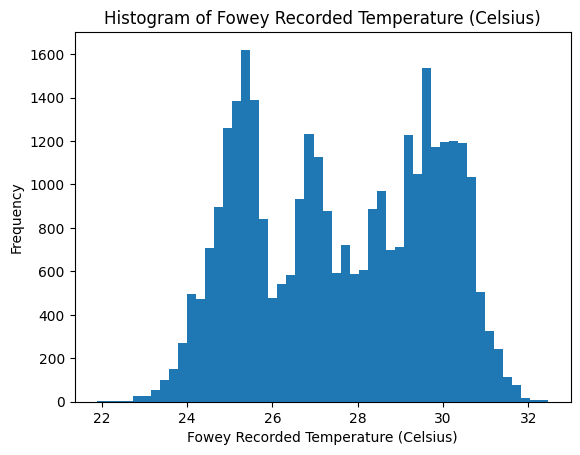

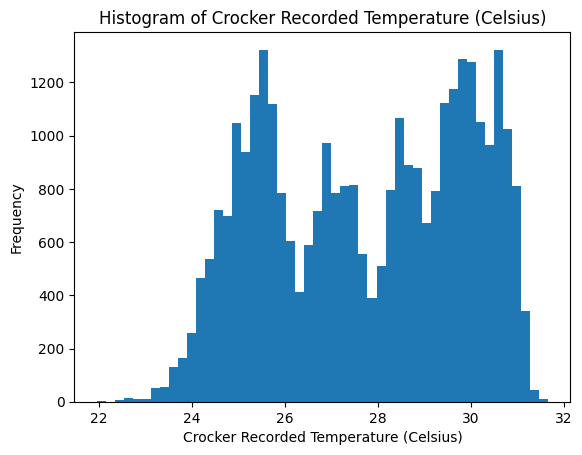

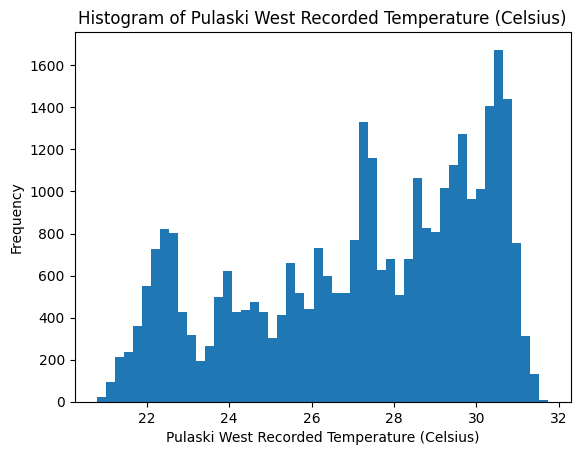

In [14]:
# histograms 
for i in df:
    print(i)
    if i!= "Sample Number (From Jan. 1-Nov. 30, 2020)":
        fig,ax = plt.subplots()
        ax.hist(df[i], bins=50)
        ax.set_xlabel(i)
        ax.set_ylabel("Frequency")
        ax.set_title("Histogram of " + i)

In [30]:
### Correlation ###
#Calculate Pearson and Spearman Correlation Coefficients between key variables relevant to your hypothesis
from scipy import stats
# Pearson and Spearman correlation for each site measuring for temp
sample_col = "Sample Number (From Jan. 1-Nov. 30, 2020)"
for col in df:
    if col != sample_col:
        x = df[sample_col] #x axis
        y = df[col] # y axis
        pear = stats.pearsonr(x, y)
        spear = stats.spearmanr(x, y)
print(" Pearson =", pear.statistic, " p =", pear.pvalue)
print(" Spearman =", spear.statistic, " p =", spear.pvalue)



 Pearson = 0.7350015663162315  p = 0.0
 Spearman = 0.6942220285594028  p = 0.0


In [27]:
# Linear Regression and Correlation
for i in df:
    if i != "Sample Number (From Jan. 1-Nov. 30, 2020)":
        linR = scipy.stats.linregress(df["Sample Number (From Jan. 1-Nov. 30, 2020)"],df[i])
        #print(i, linR)
        m=np.round(linR.slope, 6)
        b=np.round(linR.intercept,3)
        r=np.round(linR.rvalue, 3)
        p=linR.pvalue
        print(i, "   Regression Line: y="+str(m)+"x+"+str(b), ": R="+str(r), ": p="+str(p))
                                   

Pulaski Light Recorded Temperature (Celsius)    Regression Line: y=0.000229x+23.5 : R=0.755 : p=0.0
Sombrero  Recorded Temperature (Celsius)    Regression Line: y=0.000164x+25.255 : R=0.674 : p=0.0
Fowey Recorded Temperature (Celsius)    Regression Line: y=0.000157x+25.085 : R=0.684 : p=0.0
Crocker Recorded Temperature (Celsius)    Regression Line: y=0.000157x+25.248 : R=0.679 : p=0.0
Pulaski West Recorded Temperature (Celsius)    Regression Line: y=0.000226x+23.614 : R=0.735 : p=0.0


Pulaski Light Recorded Temperature (Celsius)
Sombrero  Recorded Temperature (Celsius)
Fowey Recorded Temperature (Celsius)
Crocker Recorded Temperature (Celsius)
Pulaski West Recorded Temperature (Celsius)
Sample Number (From Jan. 1-Nov. 30, 2020)


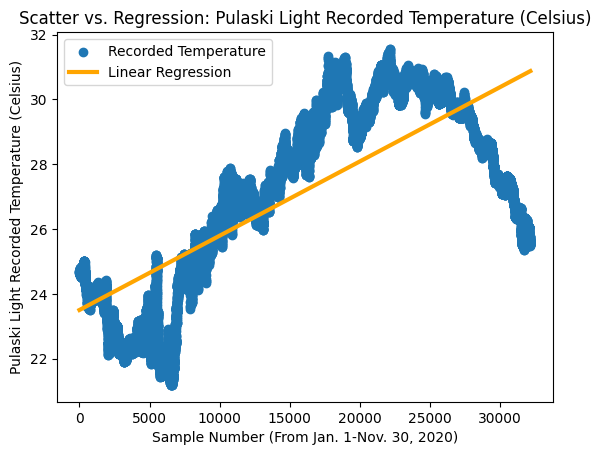

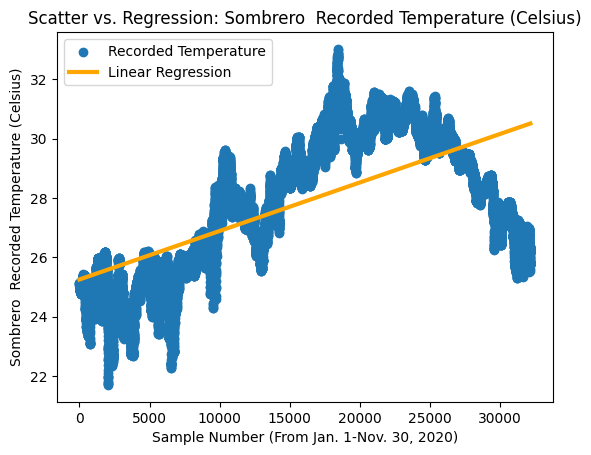

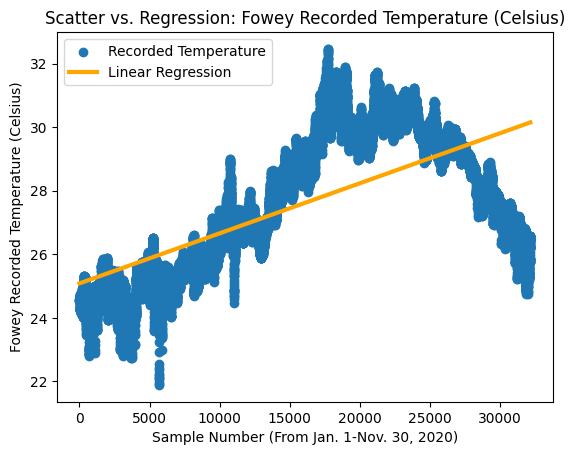

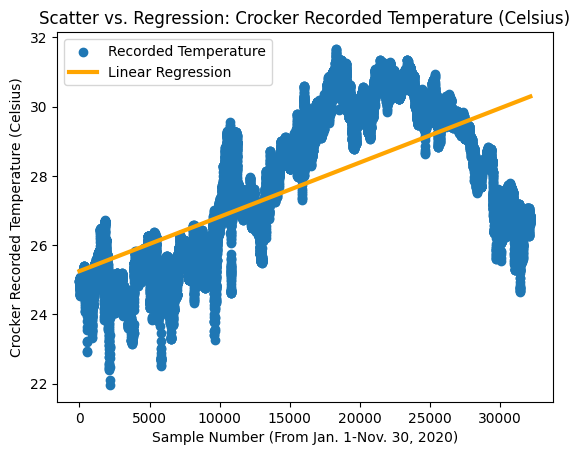

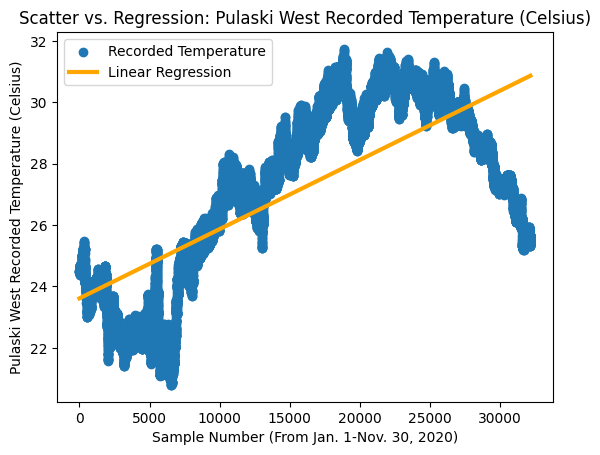

In [39]:
#fig,ax = plt.subplots()
#ax.set_xlabel('Sample Number (From Jan. 1-Nov. 30, 2020)')
#ax.set_ylabel('Sombrero  Recorded Temperature (Celsius)')
#plt.scatter(df['Sample Number (From Jan. 1-Nov. 30, 2020)'], df['Sombrero  Recorded Temperature (Celsius)'])

import matplotlib.pyplot as plt
import scipy

sample_col = "Sample Number (From Jan. 1-Nov. 30, 2020)"

for i in df:
    print(i)
    if i != sample_col:
        fig, ax = plt.subplots()
        # scatter plot of data
        ax.set_xlabel(sample_col)
        ax.set_ylabel(i)
        ax.scatter(df[sample_col], df[i])
        # linear regression line
        linR = scipy.stats.linregress(df[sample_col], df[i])
        x = [0, 0]
        y = [0, 0]
        x[0] = df[sample_col].min()
        y[0] = linR.slope * x[0] + linR.intercept
        x[1] = df[sample_col].max()
        y[1] = linR.slope * x[1] + linR.intercept
        # plot
        ax.plot(x, y, lw=3, c="orange")

        ax.set_title("Scatter vs. Regression: " + i)
        ax.legend(["Recorded Temperature", "Linear Regression"])

PC1 variance: 96.782%
PC2 variance: 1.838%


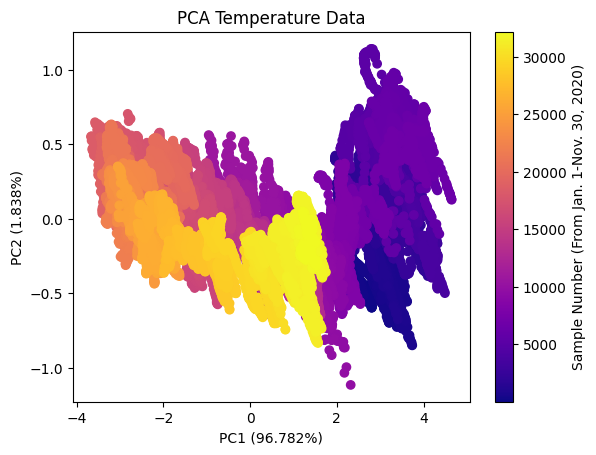

In [57]:
### Generating a PCA

sample_col = "Sample Number (From Jan. 1-Nov. 30, 2020)"
temp_cols = []
for col in df:
    if col != sample_col:
        temp_cols.append(col)

#rescaling data
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df[temp_cols])
#creating PCA analysis
pca = PCA(n_components=0.99)   # keep 99% variance
PCs = pca.fit_transform(scaled_data)

## possible outputs
# print(PCs)
# print(pca.explained_varaiance_ratio) # A list of how much each PC explains in decimals.
#print(pca.components_)
pc1pct = str(round(pca.explained_variance_ratio_[0] * 100, 3)) + "%"
pc2pct = str(round(pca.explained_variance_ratio_[1] * 100, 3)) + "%"

print("PC1 variance:", pc1pct)
print("PC2 variance:", pc2pct)
plt.figure()
plt.xlabel("PC1 (" + pc1pct + ")")
plt.ylabel("PC2 (" + pc2pct + ")")
plt.title("PCA Temperature Data")

plt.scatter(PCs[:, 0],PCs[:, 1],c=df[sample_col],cmap="plasma")

plt.colorbar(label=sample_col)
plt.show()